In [2]:
pip install scikit-learn

In [8]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# set matplotlib inline
%matplotlib inline
# set seaborn as main style
import seaborn as sns
# to display available styles, use: print(plt.style.available)
plt.style.use('seaborn-v0_8')

# filter warnings
import warnings
warnings.filterwarnings('ignore')
from sklearn import linear_model

In [11]:
# use seabonrn 'tips' dataset from the restaurant business
df1 = sns.load_dataset('tips')
# check data
df1.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
# use info to get number of rows and columns
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [13]:
# drop all columns except total_bill and tip
df1 = df1.drop(df1.iloc[:,2:7], axis = 1)
df1.head()

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61


In [14]:
# find average tip
df1['tip'].mean()

2.99827868852459

Text(0, 0.5, 'tips')

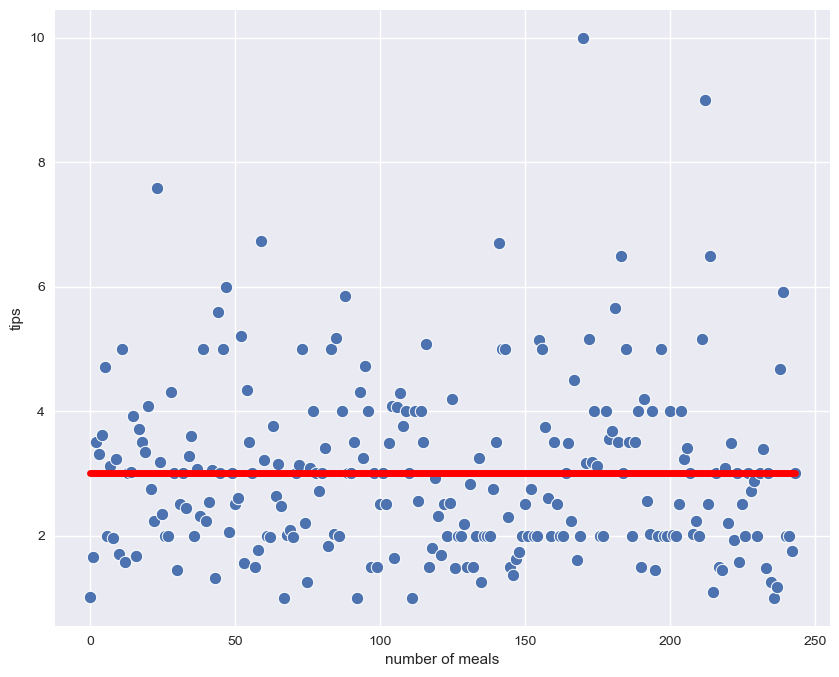

In [23]:
# set screansize (note: in inches 10 x 8) and plot tips with marker size s = 80
plt.figure(figsize = (10,8))
sns.scatterplot(data = df1['tip'], s = 80)
# add lineplot with average tip
sns.lineplot(x = df1.index, y= df1['tip'].mean(), linewidth = 5, color = 'r')
plt.xlabel('number of meals')
plt.ylabel('tips')

Text(0, 0.5, 'tips')

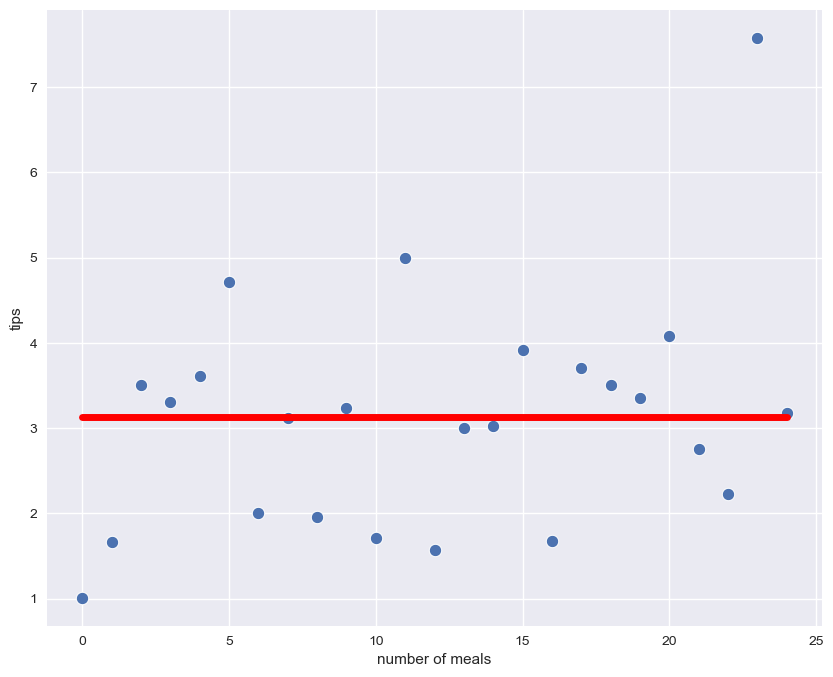

In [24]:
# only show tips for 1st 25 meals:
plt.figure(figsize = (10,8))
sns.scatterplot(data = df1['tip'].head(25), s = 80)
# add lineplot with average tip
sns.lineplot(x = df1.index[:25], y= df1['tip'].head(25).mean(), linewidth = 5, color = 'r')
plt.xlabel('number of meals')
plt.ylabel('tips')

Text(0, 0.5, 'tips')

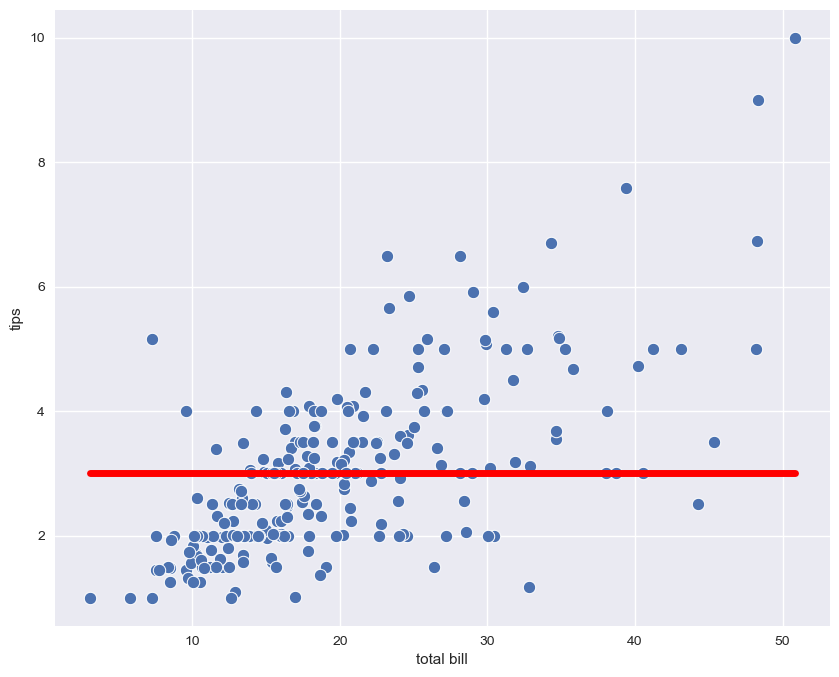

In [26]:
# plot tips vs total_bill
plt.figure(figsize = (10,8))
sns.scatterplot(x = df1['total_bill'], y = df1['tip'], s = 80)
# add lineplot with average tip
sns.lineplot(x = df1['total_bill'], y= df1['tip'].mean(), linewidth = 5, color = 'r')
plt.xlabel('total bill')
plt.ylabel('tips')

In [28]:
# use machine learning to estimate future tips
# first, split data to training data and test data using sklearn train_test_split
from sklearn.model_selection import train_test_split

In [37]:
# convert data from dataframe to 2D numpy array (total_bill x tips) with total_bill - use reshape to remove index and create 2D array
# split to 75% train and 25% test data (note: test_size = 0.25 is the default)
# rule of tumb is to use 60 - 80% of the data as training data and remaining as testing data
X_train, X_test, y_train, y_test = train_test_split(np.array(df1['total_bill']).reshape(-1,1), np.array(df1['tip']), test_size = 0.25)

In [39]:
# create linear regression model
lr = linear_model.LinearRegression()

In [40]:
# use fit() method to specify traing data
lr.fit(X_train, y_train)

LinearRegression()

In [41]:
# predict tips
predicted_tips = lr.predict(X_test)

<Axes: >

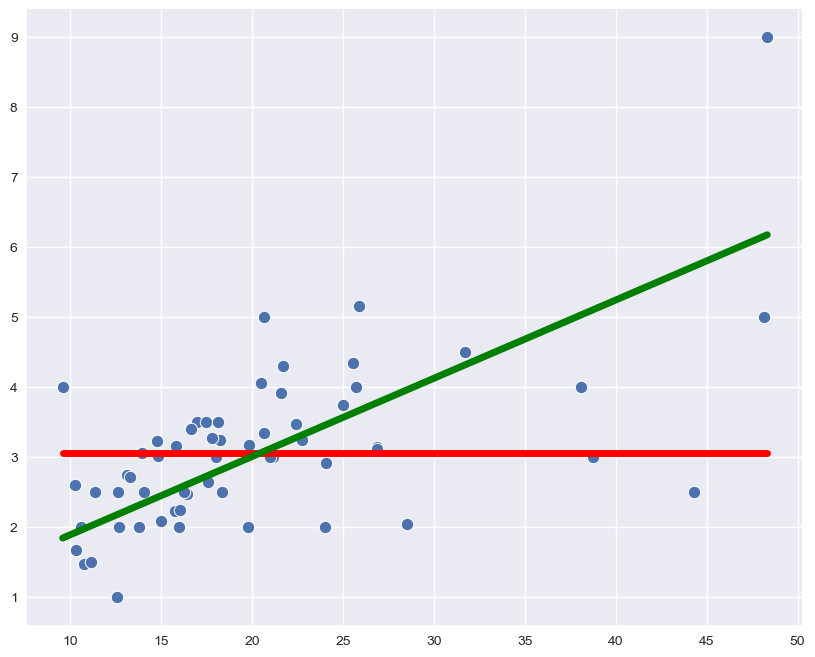

In [44]:
# visualize predicted tips against test data tips
plt.figure(figsize = (10,8))
sns.scatterplot(x = X_test.flatten(), y = y_test, s = 80)
# add lineplot with average test data tips
sns.lineplot(x = X_test.flatten(), y= y_test.mean(), linewidth = 5, color = 'r')
# add lineplot with predicted tips
sns.lineplot(x = X_test.flatten(), y= predicted_tips, linewidth = 5, color = 'g')

In [45]:
# add predicted tips to tips dataframe
df1['predicted_tips'] = lr.predict(np.array(df1['total_bill']).reshape(-1,1))

In [46]:
# verify predicted data was added to dataframe
df1.head()

,total_bill,tip,predicted_tips
0,16.99,1.01,2.672835
1,10.34,1.66,1.929075
2,21.01,3.50,3.122447
3,23.68,3.31,3.421069
4,24.59,3.61,3.522847


In [47]:
# check linear score
lr.score(X_test, y_test)

0.33543724480995474